# Storing `jaxvacua.vacuum` objects

StringForge's writers accept a `jaxvacua.vacuum.Vacuum` (or `PFV` / `AFV`)
**directly** — no manual flattening to arrays.  One call stores a list of vacua
spanning any number of geometries, and read-back reconstructs the *exact*
objects.

The authoritative record is the JSON-encoded `Vacuum.to_dict()` stashed in the
free `extra_data` column (never `pickle` — the vault is public, so an
unpickle-on-load would be a remote-code-execution vector).  The typed columns
(`moduli`, `tau`, `flux`, `residual`, `W`, `N_flux`, …) remain the queryable
projection.

This notebook uses **real vacua**: `dataset_B`, 12196 solved $h^{2,1}=2$ flux
vacua for the degree-18 hypersurface in $\mathbb{CP}^{1,1,1,6,9}$
(`model_ID=1`, $Q_{D3}=276$) — the literature-validation set used in the
flux-bounding notebooks.

## Setup

In [1]:
import os, tempfile, gzip, pickle, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Write to a throwaway vault so the tutorial never touches your real store.
os.environ['STRINGFORGE_VAULT'] = tempfile.mkdtemp()

import jaxvacua as jvc; jvc.set_precision('float64')
from jaxvacua.vacuum import Vacuum
from stringforge.lcs_database import LCSDatabase
print('jaxvacua', jvc.__version__)

jaxvacua 0.1.2


## Load real vacua

`dataset_B` ships as a gzip-pickled `(12196, 18)` array; each row is
`[x(6), flux(12)]` — the real coordinate vector `x` (two complex moduli + the
axio-dilaton) followed by the length-12 integer flux vector.

In [2]:
repo = Path(jvc.__file__).resolve().parents[1]
ds = repo/'documentation'/'source'/'notebooks'/'02_vacuum_finding'/'dataset_B.p'
with gzip.open(ds, 'rb') as f:
    A = pickle.load(f)
print(f'dataset_B: {A.shape[0]} real h12=2 vacua, layout [x(6), flux(12)]')

dataset_B: 12196 real h12=2 vacua, layout [x(6), flux(12)]


/var/folders/p7/f3t072gd3rbfgb00y3hj7dwc0000gn/T/ipykernel_87863/677447594.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  A = pickle.load(f)


## Build `Vacuum` objects

We attach the `model_ID=1` finder to recompute each vacuum's diagnostics
($W_0$, $D_IW$, residual, $g_s$).  The conifold diagnostics
(`zcf` / `alignment` / `residual_conifold`) are `None` — legitimately *not
applicable* to a pure-LCS vacuum — so every object is **NaN-free**.

In [3]:
finder = jvc.FluxVacuaFinder(h12=2, model_ID=1, maximum_degree=2)

def to_vacuum(row, tol=1e-4):
    x = np.asarray(row[:6], float); flux = np.asarray(row[6:18], float)
    z, _, tau, _ = finder._convert_real_to_complex(x)
    DW = np.asarray(finder.DW_x(x, flux)); res = float(np.max(np.abs(DW)))
    W0 = complex(finder.W(z, tau, flux, normalise=True))
    return Vacuum(x=x, flux=flux, W0=W0, DW=DW, residual=res,
                  residual_bulk=res, residual_conifold=None,
                  zcf=None, gs=float(1/tau.imag), alignment=None,
                  success=bool(res < tol), genealogy=['dataset_B'],
                  metadata={'model_name': 'CP11169_deg18'})

N = 250
vacua = [to_vacuum(A[i]) for i in range(N)]
print(f'built {len(vacua)} Vacuum objects | solved (res<1e-4): '
      f'{sum(v.is_solved() for v in vacua)}')

built 250 Vacuum objects | solved (res<1e-4): 206


## Store them — one call

`db.write_vacua` groups the vacua by geometry, opens one streaming writer per
geometry, and returns a `WriteReport`.  Passing `models=finder` lets it stamp
the geometry-independent D3 tadpole `N_flux = finder.tadpole(flux)` on every
row.

In [4]:
db = LCSDatabase(dataset='tdf', cache_dir=tempfile.mkdtemp(), offline=True)
report = db.write_vacua(vacua, models=finder)
print(report)
run_id = report.run_ids_by_geometry['CP11169_deg18']

WriteReport(n_written=206, n_duplicates=0, geometries=['CP11169_deg18'])


## Read them back — exact

`db.read_vacua` rebuilds the `Vacuum` objects from the stored record
(finder-free).  The queryable typed columns are still available through the
unchanged `load_vacua` / `query_vacua` DataFrame path.

In [5]:
got = db.read_vacua(run_id)
# write_vacua stored the solved subset (only_solved=True); compare like-for-like
written = [v for v in vacua if v.is_solved()]
exact = all(a.equals(b) for a, b in zip(written, got))
print(f'read back {len(got)} Vacuum objects (the solved subset) | all exact: {exact}')

dfq = db.load_vacua(run_id)
cols = ['flux','moduli_re','moduli_im','tau_re','tau_im','N_flux','W_re','residual']
print('queryable columns:', [c for c in cols if c in dfq.columns])
dfq[['tau_im','N_flux','W_re','residual']].head()

read back 206 Vacuum objects (the solved subset) | all exact: True
queryable columns: ['flux', 'moduli_re', 'moduli_im', 'tau_re', 'tau_im', 'N_flux', 'W_re', 'residual']


,tau_im,N_flux,W_re,residual
0,1.005013,9,-42.117417,0.000001
1,1.005013,9,42.117417,0.000001
2,1.246215,10,5.112692,0.000028
3,1.246215,10,-5.112692,0.000028
4,1.270350,10,20.650255,0.000003


## The stored ensemble

Because the typed projection is queryable, the stored run is immediately
plottable — here the $(g_s, |W_0|)$ distribution coloured by D3 tadpole, and the
tadpole histogram.

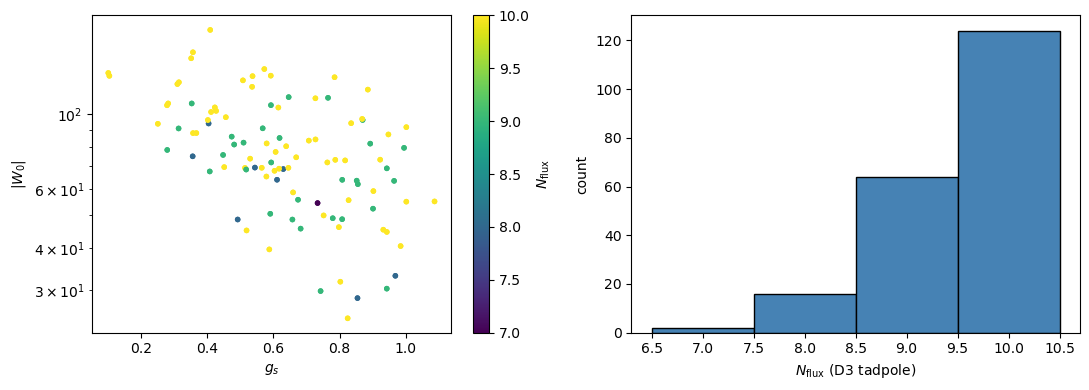

In [6]:
gs    = np.array([v.gs for v in got])
absW0 = np.array([abs(v.W0) for v in got])
Nflux = np.asarray(dfq['N_flux'], dtype=float)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sc = ax[0].scatter(gs, absW0, c=Nflux, cmap='viridis', s=16, edgecolor='none')
ax[0].set_xlabel(r'$g_s$'); ax[0].set_ylabel(r'$|W_0|$'); ax[0].set_yscale('log')
plt.colorbar(sc, ax=ax[0], label=r'$N_{\rm flux}$')

lo, hi = int(np.nanmin(Nflux)), int(np.nanmax(Nflux))
ax[1].hist(Nflux, bins=range(lo, hi + 2), color='steelblue', edgecolor='k', align='left')
ax[1].set_xlabel(r'$N_{\rm flux}$ (D3 tadpole)'); ax[1].set_ylabel('count')
fig.tight_layout(); plt.show()

## The record is JSON, not pickle

The exact object travels in `extra_data` as JSON — inspectable, portable, and
safe to load from an untrusted source.

In [7]:
blob = json.loads(dfq['extra_data'].iloc[0])
print('extra_data keys :', list(blob.keys()))
print('record _kind    :', blob['vacuum']['_kind'])
print('round-trips exact:', got[0].equals(vacua[0]))

extra_data keys : ['vacuum', 'kind', 'model_name']
record _kind    : Vacuum
round-trips exact: True


## Production tier (Vulcan)

The same adapter backs the high-volume `vulcan` writer, which stages parquet
shards for HuggingFace publishing:

```python
from stringforge.vulcan import Vulcan
vulc = Vulcan(repo='your-org/your-dataset')
shard = vulc.write_vacua(vacua, finder=finder)   # one shard per geometry
back  = vulc.read_vacua(shard)                    # exact reconstruction
```

## Summary

- `db.write_vacua(vacua, models=finder)` / `db.read_vacua(run_id)` store and
  reconstruct `Vacuum` objects exactly, in one call.
- Advanced streaming: `with db.vacua_writer(model=finder) as w: w.append(vac)`.
- The record is JSON in `extra_data` (no pickle); the typed columns stay
  queryable; the production `vulcan` tier mirrors the same API.